# 03-1. LightGBM モデル設計 — 2026-03-08

## リクルート飲食店来客数予測コンペティション

**目的**: 02で確定した特徴量セットと前提条件を使い、LightGBMモデルを構築・チューニングする。

### 本ノートブックの構成
1. データ読み込み（中間データから）
2. モデル概要と選定理由
3. ハイパーパラメータ設定（初期値）
4. 時系列バリデーションによる学習
5. 予測結果の分析
6. 特徴量重要度の分析
7. 残差分析
8. ハイパーパラメータチューニング（Optuna）
9. まとめと次ステップ

---
## 1. データ読み込み（中間データから）

02ノートブックで保存した `02_feature_design.pkl` を読み込み、特徴量の再計算を省略する。

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'

SEED = 42
np.random.seed(SEED)
INTERMEDIATE_DIR = Path('./intermediate')

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 1, None)  # 来客数は1人以上（テスト期間に休業日は含まれない）
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# 中間データの読み込み
with open(INTERMEDIATE_DIR / '02_feature_design.pkl', 'rb') as f:
    prev = pickle.load(f)

train_df = prev['train_features']
valid_df = prev['valid_features']
all_features = prev['feature_columns']['all_features']
scores_02 = prev['scores']
VALID_START = prev['VALID_START']

# 02で確定した前提条件を適用
settings = prev['confirmed_settings']
TRAIN_START = settings['best_train_start']
NAN_STRATEGY = settings['best_nan_strategy']

# 01 EDAで設計したval_folds（5フォールド時系列CV）を読み込み
val_folds = prev['val_folds']
print(f'  CV戦略: {len(val_folds)}フォールド時系列CV（01 EDA設計）')
for i, fold in enumerate(val_folds):
    print(f'    Fold {i+1}: val_start={fold["val_start"]}, val_end={fold["val_end"]}')

# 学習データ期間のフィルタリング
train_df = train_df[train_df['visit_date'] >= TRAIN_START].copy()

print('\n中間データ読み込み完了')
print(f'  学習データ: {train_df.shape} (期間: {TRAIN_START}～)')
print(f'  検証データ: {valid_df.shape}')
print(f'  特徴量数: {len(all_features)}')
print(f'\n=== 02で確定した前提条件 ===')
print(f'  学習データ期間: {settings["best_train_period"]} (start={TRAIN_START})')
print(f'  NaN処理: {NAN_STRATEGY}')
print(f'  Rolling構成: {settings["best_rolling_config"]}')
print(f'\n02での最終スコア（参考）: RMSLE = {scores_02["score_all"]:.5f}')

  CV戦略: 5フォールド時系列CV（01 EDA設計）
    Fold 1: val_start=2016-04-23, val_end=2016-05-31
    Fold 2: val_start=2016-07-16, val_end=2016-08-23
    Fold 3: val_start=2016-10-15, val_end=2016-11-22
    Fold 4: val_start=2016-12-16, val_end=2017-01-23
    Fold 5: val_start=2017-03-15, val_end=2017-04-22

中間データ読み込み完了
  学習データ: (222073, 60) (期間: 2015-12-12～)
  検証データ: (30035, 60)
  特徴量数: 53

=== 02で確定した前提条件 ===
  学習データ期間: 直近15ヶ月 (start=2015-12-12)
  NaN処理: NaN(デフォルト)
  Rolling構成: 現行のみ

02での最終スコア（参考）: RMSLE = 0.51636


---
## 1b. 予約データ特徴量の追加（HPG + Air）

### 背景
- HPG予約データ（200万件）が未活用 — 最大の未開拓リソース
- リンク可能店舗は150/829のみだが、**エリア集計**なら全店舗に適用可能
- 1位の解法もHPGエリア集計を活用

### 追加する特徴量

| 特徴量 | 粒度 | カバー率 | 説明 |
|--------|------|---------|------|
| `hpg_city_reserve_visitors` | city×date | 94% | HPG市区町村別の予約合計人数 |
| `hpg_city_reserve_count` | city×date | 94% | HPG市区町村別の予約件数 |
| `hpg_pref_reserve_visitors` | prefecture×date | 100% | HPG都道府県別の予約合計人数 |
| `hpg_store_reserve_visitors` | store×date | 18% | HPGリンク店舗の直接予約人数 |
| `air_reserve_visitors` | store×date | 38% | Air予約の合計人数 |
| `air_reserve_count` | store×date | 38% | Air予約の件数 |
| `total_reserve_visitors` | store×date | — | HPG直接+Air予約の合計 |

In [26]:
# === 予約データ特徴量の構築 ===
INPUT_DIR = Path('../../input')

# --- データ読み込み ---
hpg_res = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
air_res = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_store_info = pd.read_csv(INPUT_DIR / 'hpg_store_info.csv')
air_store_info = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
store_rel = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')

# visit_dateを日付に変換
hpg_res['visit_date'] = hpg_res['visit_datetime'].dt.normalize()
air_res['visit_date'] = air_res['visit_datetime'].dt.normalize()

# --- HPGエリア情報の付与 ---
hpg_res = hpg_res.merge(hpg_store_info[['hpg_store_id', 'hpg_area_name']], on='hpg_store_id', how='left')
hpg_res['city'] = hpg_res['hpg_area_name'].str.split(' ').str[:2].str.join(' ')
hpg_res['prefecture'] = hpg_res['hpg_area_name'].str.split(' ').str[0]

# Airの店舗にもcity/prefectureを付与
air_store_info['city'] = air_store_info['air_area_name'].str.split(' ').str[:2].str.join(' ')
air_store_info['prefecture'] = air_store_info['air_area_name'].str.split(' ').str[0]

# --- Feature 1: HPG city-level daily reservation ---
hpg_city_daily = hpg_res.groupby(['city', 'visit_date']).agg(
    hpg_city_reserve_visitors=('reserve_visitors', 'sum'),
    hpg_city_reserve_count=('reserve_visitors', 'count')
).reset_index()

# --- Feature 2: HPG prefecture-level daily reservation ---
hpg_pref_daily = hpg_res.groupby(['prefecture', 'visit_date']).agg(
    hpg_pref_reserve_visitors=('reserve_visitors', 'sum'),
).reset_index()

# --- Feature 3: HPG direct store reservation (150 linked stores) ---
hpg_direct = hpg_res.merge(store_rel, on='hpg_store_id', how='inner')
hpg_store_daily = hpg_direct.groupby(['air_store_id', 'visit_date']).agg(
    hpg_store_reserve_visitors=('reserve_visitors', 'sum'),
).reset_index()

# --- Feature 4: Air direct store reservation ---
air_store_daily = air_res.groupby(['air_store_id', 'visit_date']).agg(
    air_reserve_visitors=('reserve_visitors', 'sum'),
    air_reserve_count=('reserve_visitors', 'count')
).reset_index()

# --- train_df / valid_df にマージ ---
def add_reserve_features(df):
    """予約特徴量をDataFrameに追加"""
    df = df.copy()
    
    # Air store → city/prefecture mapping
    store_city = air_store_info.set_index('air_store_id')[['city', 'prefecture']]
    df = df.merge(store_city, left_on='air_store_id', right_index=True, how='left', suffixes=('', '_res'))
    
    # HPG city-level
    df = df.merge(hpg_city_daily, on=['city', 'visit_date'], how='left')
    
    # HPG prefecture-level
    df = df.merge(hpg_pref_daily, on=['prefecture', 'visit_date'], how='left')
    
    # HPG direct store
    df = df.merge(hpg_store_daily, on=['air_store_id', 'visit_date'], how='left')
    
    # Air direct store
    df = df.merge(air_store_daily, on=['air_store_id', 'visit_date'], how='left')
    
    # Total reservation (HPG direct + Air)
    df['total_reserve_visitors'] = df[['hpg_store_reserve_visitors', 'air_reserve_visitors']].sum(axis=1, min_count=1)
    
    # NaN → 0 for reserve counts (no reservation = 0, not missing)
    reserve_cols = ['hpg_city_reserve_visitors', 'hpg_city_reserve_count',
                    'hpg_pref_reserve_visitors', 'hpg_store_reserve_visitors',
                    'air_reserve_visitors', 'air_reserve_count', 'total_reserve_visitors']
    for col in reserve_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    # city/prefectureカラムを削除（エンコーディング済みのarea_encodedがある）
    df.drop(columns=['city', 'prefecture'], errors='ignore', inplace=True)
    if 'city_res' in df.columns:
        df.drop(columns=['city_res', 'prefecture_res'], errors='ignore', inplace=True)
    
    return df

# 学習・検証データに適用
train_df = add_reserve_features(train_df)
valid_df = add_reserve_features(valid_df)

# 新しい特徴量リスト
reserve_features = ['hpg_city_reserve_visitors', 'hpg_city_reserve_count',
                    'hpg_pref_reserve_visitors', 'hpg_store_reserve_visitors',
                    'air_reserve_visitors', 'air_reserve_count', 'total_reserve_visitors']
all_features_v2 = all_features + reserve_features

print(f'=== 予約特徴量の追加完了 ===')
print(f'  元の特徴量数: {len(all_features)}')
print(f'  追加特徴量: {len(reserve_features)}')
print(f'  合計: {len(all_features_v2)}')
print(f'\n  予約データのカバー率（学習データ）:')
for col in reserve_features:
    non_zero = (train_df[col] > 0).mean() * 100
    print(f'    {col}: {non_zero:.1f}% (非ゼロ率)')
print(f'\n  予約データのカバー率（検証データ）:')
for col in reserve_features:
    non_zero = (valid_df[col] > 0).mean() * 100
    print(f'    {col}: {non_zero:.1f}% (非ゼロ率)')

=== 予約特徴量の追加完了 ===
  元の特徴量数: 53
  追加特徴量: 7
  合計: 60

  予約データのカバー率（学習データ）:
    hpg_city_reserve_visitors: 92.5% (非ゼロ率)
    hpg_city_reserve_count: 92.5% (非ゼロ率)
    hpg_pref_reserve_visitors: 100.0% (非ゼロ率)
    hpg_store_reserve_visitors: 5.2% (非ゼロ率)
    air_reserve_visitors: 10.1% (非ゼロ率)
    air_reserve_count: 10.1% (非ゼロ率)
    total_reserve_visitors: 13.3% (非ゼロ率)

  予約データのカバー率（検証データ）:
    hpg_city_reserve_visitors: 93.1% (非ゼロ率)
    hpg_city_reserve_count: 93.1% (非ゼロ率)
    hpg_pref_reserve_visitors: 100.0% (非ゼロ率)
    hpg_store_reserve_visitors: 6.5% (非ゼロ率)
    air_reserve_visitors: 18.5% (非ゼロ率)
    air_reserve_count: 18.5% (非ゼロ率)
    total_reserve_visitors: 20.7% (非ゼロ率)


---
## 2. モデル概要と選定理由

### LightGBMを最初のモデルとして選ぶ理由

| 理由 | 詳細 |
|------|------|
| 高速な学習 | Histogram-based splittingにより大規模データでも高速 |
| 欠損値処理 | NaN（ラグ特徴量の初期値等）を自動的に処理 |
| カテゴリ変数 | Optimal split for categoricalを内蔵 |
| 上位解法での実績 | このコンペの上位解法の大半がLightGBMを使用 |
| チューニングの容易さ | 少ないパラメータで十分な性能を発揮 |

### 学習方針
- 目的変数: `log1p(visitors)` → RMSEで学習 = RMSLE最適化と等価
- 検証: 時系列分割（未来のデータで評価）

---
## 3. ハイパーパラメータ設定

### パラメータの選定根拠

| パラメータ | 値 | 根拠 |
|-----------|-----|------|
| `num_leaves` | 63 | 中規模の木（デフォルト31より表現力を高める） |
| `learning_rate` | 0.02 | 低めに設定し、多くのイテレーションで精度を稼ぐ |
| `n_estimators` | 2000 | early_stoppingで自動決定するため大きめに設定 |
| `subsample` | 0.8 | 過学習抑制（全データの80%で各木を学習） |
| `colsample_bytree` | 0.8 | 特徴量のランダム選択で過学習抑制 |
| `min_child_samples` | 20 | リーフの最小サンプル数（過学習防止） |
| `reg_alpha` | 0.1 | L1正則化 |
| `reg_lambda` | 0.1 | L2正則化 |

In [27]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.02,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': SEED,
    'verbose': -1,
    'n_jobs': -1,
}

print('=== LightGBM ハイパーパラメータ ===')
for k, v in lgb_params.items():
    print(f'  {k}: {v}')

=== LightGBM ハイパーパラメータ ===
  objective: regression
  metric: rmse
  boosting_type: gbdt
  num_leaves: 63
  learning_rate: 0.02
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_samples: 20
  reg_alpha: 0.1
  reg_lambda: 0.1
  random_state: 42
  verbose: -1
  n_jobs: -1


---
## 4. 時系列バリデーションによる学習

### バリデーション戦略

時系列データのため、**未来をリークしない分割**が必須。

- **Single split**: 学習 (～2017/3/11) → 検証 (2017/3/12～)
- **TimeSeriesSplit (3-fold)**: 時系列に沿った3分割でCV

まずSingle splitで学習し、次にCVで安定性を確認する。

In [28]:
# === Single Split での学習（予約特徴量追加版 v2） ===
X_train = train_df[all_features_v2]
y_train = np.log1p(train_df['visitors'])
X_valid = valid_df[all_features_v2]
y_valid = np.log1p(valid_df['visitors'])

dtrain = lgb.Dataset(X_train, label=y_train)
dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=100, verbose=True),
    lgb.log_evaluation(period=200),
]

model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=callbacks,
)

# 予測
pred_log = model.predict(X_valid)
pred = np.expm1(pred_log)
score_single = rmsle(valid_df['visitors'], pred)

print(f'\n=== Single Split 結果（{len(all_features_v2)}特徴量） ===')
print(f'  Best iteration: {model.best_iteration}')
print(f'  RMSLE: {score_single:.5f}')
print(f'  02での簡易モデルスコア: {scores_02["score_all"]:.5f}')
print(f'  改善幅: {scores_02["score_all"] - score_single:.5f}')

Training until validation scores don't improve for 100 rounds
[200]	train's rmse: 0.482739	valid's rmse: 0.511017
[400]	train's rmse: 0.47048	valid's rmse: 0.505067
[600]	train's rmse: 0.463222	valid's rmse: 0.503784
[800]	train's rmse: 0.456989	valid's rmse: 0.503218
[1000]	train's rmse: 0.451226	valid's rmse: 0.502809
Early stopping, best iteration is:
[1099]	train's rmse: 0.44854	valid's rmse: 0.502534

=== Single Split 結果（60特徴量） ===
  Best iteration: 1099
  RMSLE: 0.50253
  02での簡易モデルスコア: 0.51636
  改善幅: 0.01382


In [29]:
# === 時系列 Cross-Validation（01 EDAで設計した5フォールド） ===
# 予約特徴量追加版（all_features_v2）で評価
full_df = pd.concat([train_df, valid_df], ignore_index=True).sort_values('visit_date').reset_index(drop=True)

cv_scores = []
cv_models = []

for i, fold in enumerate(val_folds, 1):
    val_start = pd.Timestamp(fold['val_start'])
    val_end = pd.Timestamp(fold['val_end'])
    
    train_mask = full_df['visit_date'] < val_start
    valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)
    
    fold_train = full_df[train_mask]
    fold_valid = full_df[valid_mask]
    
    if len(fold_train) == 0 or len(fold_valid) == 0:
        print(f'Fold {i}: スキップ（データ不足）')
        continue
    
    X_tr = fold_train[all_features_v2]
    y_tr = np.log1p(fold_train['visitors'])
    X_va = fold_valid[all_features_v2]
    y_va_raw = fold_valid['visitors']
    
    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=np.log1p(y_va_raw), reference=dtr)
    
    m = lgb.train(
        lgb_params, dtr, num_boost_round=2000,
        valid_sets=[dva], valid_names=['valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    
    p = np.expm1(m.predict(X_va))
    s = rmsle(y_va_raw, p)
    cv_scores.append(s)
    cv_models.append(m)
    
    print(f'Fold {i}: RMSLE={s:.5f}  '
          f'(train: {fold_train["visit_date"].min().date()}~{fold_train["visit_date"].max().date()}, '
          f'valid: {fold["val_start"]}~{fold["val_end"]}, '
          f'n_train={len(fold_train):,}, n_valid={len(fold_valid):,}, '
          f'best_iter={m.best_iteration})')

print(f'\n=== CV結果（5フォールド, {len(all_features_v2)}特徴量） ===')
print(f'  平均 RMSLE: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})')
print(f'  各Fold: {[f"{s:.5f}" for s in cv_scores]}')

Fold 1: RMSLE=0.50557  (train: 2016-01-01~2016-04-22, valid: 2016-04-23~2016-05-31, n_train=29,116, n_valid=10,336, best_iter=453)
Fold 2: RMSLE=0.50840  (train: 2016-01-01~2016-07-15, valid: 2016-07-16~2016-08-23, n_train=58,174, n_valid=26,084, best_iter=238)
Fold 3: RMSLE=0.48354  (train: 2016-01-01~2016-10-14, valid: 2016-10-15~2016-11-22, n_train=120,279, n_valid=27,168, best_iter=454)
Fold 4: RMSLE=0.51849  (train: 2016-01-01~2016-12-15, valid: 2016-12-16~2017-01-23, n_train=163,715, n_valid=24,817, best_iter=995)
Fold 5: RMSLE=0.48839  (train: 2016-01-01~2017-03-14, valid: 2017-03-15~2017-04-22, n_train=224,077, n_valid=28,031, best_iter=1234)

=== CV結果（5フォールド, 60特徴量） ===
  平均 RMSLE: 0.50088 (+/- 0.01300)
  各Fold: ['0.50557', '0.50840', '0.48354', '0.51849', '0.48839']


### 4b. 予約特徴量追加の効果検証（CV比較）

予約特徴量7個を追加した `all_features_v2` で同じ5フォールドCVを実施し、改善幅を定量化する。

In [30]:
# === 予約特徴量の効果検証: v1（53特徴量） vs v2（60特徴量） ===
# v1（予約なし）でもCVを実施して比較
cv_scores_v1 = []
for i, fold in enumerate(val_folds, 1):
    val_start = pd.Timestamp(fold['val_start'])
    val_end = pd.Timestamp(fold['val_end'])
    
    train_mask = full_df['visit_date'] < val_start
    valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)
    
    fold_train = full_df[train_mask]
    fold_valid = full_df[valid_mask]
    
    if len(fold_train) == 0 or len(fold_valid) == 0:
        continue
    
    X_tr = fold_train[all_features]
    y_tr = np.log1p(fold_train['visitors'])
    X_va = fold_valid[all_features]
    y_va_raw = fold_valid['visitors']
    
    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=np.log1p(y_va_raw), reference=dtr)
    
    m = lgb.train(
        lgb_params, dtr, num_boost_round=2000,
        valid_sets=[dva], valid_names=['valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    
    p = np.expm1(m.predict(X_va))
    s = rmsle(y_va_raw, p)
    cv_scores_v1.append(s)

print(f'=== 予約特徴量の効果比較 ===')
print(f'  {"Fold":<8s} {"v1(53特徴量)":>14s} {"v2(60特徴量)":>14s} {"改善幅":>10s}')
print(f'  {"-"*50}')
for i, (s1, s2) in enumerate(zip(cv_scores_v1, cv_scores), 1):
    diff = s1 - s2
    print(f'  Fold {i:<3d} {s1:>14.5f} {s2:>14.5f} {diff:>+10.5f}')
print(f'  {"-"*50}')
print(f'  {"平均":<8s} {np.mean(cv_scores_v1):>14.5f} {np.mean(cv_scores):>14.5f} {np.mean(cv_scores_v1)-np.mean(cv_scores):>+10.5f}')
print(f'  {"±std":<8s} {np.std(cv_scores_v1):>14.5f} {np.std(cv_scores):>14.5f}')
improvement = np.mean(cv_scores_v1) - np.mean(cv_scores)
print(f'\n  改善幅 {improvement:+.5f} は CV std の {improvement / np.std(cv_scores_v1) * 100:.1f}%')
print(f'  → 予約特徴量は全フォールドで改善しており、有効。')

=== 予約特徴量の効果比較 ===
  Fold          v1(53特徴量)      v2(60特徴量)        改善幅
  --------------------------------------------------
  Fold 1          0.51978        0.50557   +0.01421
  Fold 2          0.51009        0.50840   +0.00169
  Fold 3          0.49293        0.48354   +0.00939
  Fold 4          0.54166        0.51849   +0.02317
  Fold 5          0.50311        0.48839   +0.01472
  --------------------------------------------------
  平均              0.51351        0.50088   +0.01264
  ±std            0.01658        0.01300

  改善幅 +0.01264 は CV std の 76.2%
  → 予約特徴量は全フォールドで改善しており、有効。


In [31]:
# === ルールベースベースライン: 店舗×曜日の過去中央値 ===
# 上位解法の知見: store×DOW中央値はGBDTに匹敵し、アンサンブルで補完効果がある
train_df_with_dow = train_df.copy()
train_df_with_dow['dow'] = train_df_with_dow['visit_date'].dt.dayofweek

store_dow_median = train_df_with_dow.groupby(['air_store_id', 'dow'])['visitors'].median()
global_median = train_df['visitors'].median()

valid_df_with_dow = valid_df.copy()
valid_df_with_dow['dow'] = valid_df_with_dow['visit_date'].dt.dayofweek

baseline_pred = valid_df_with_dow.apply(
    lambda r: store_dow_median.get((r['air_store_id'], r['dow']), global_median), axis=1)
baseline_rmsle = rmsle(valid_df['visitors'], baseline_pred)

print(f'=== ルールベースベースライン ===')
print(f'  store×DOW中央値 RMSLE: {baseline_rmsle:.5f}')
print(f'  LightGBM Single Split: {score_single:.5f}')
print(f'  改善幅: {baseline_rmsle - score_single:.5f}')
print(f'\n  ※ このベースラインは04のアンサンブルで使用する')

=== ルールベースベースライン ===
  store×DOW中央値 RMSLE: 0.54977
  LightGBM Single Split: 0.50253
  改善幅: 0.04724

  ※ このベースラインは04のアンサンブルで使用する


---
## 5. 予測結果の分析

Single Splitモデルの予測を詳細に分析する。

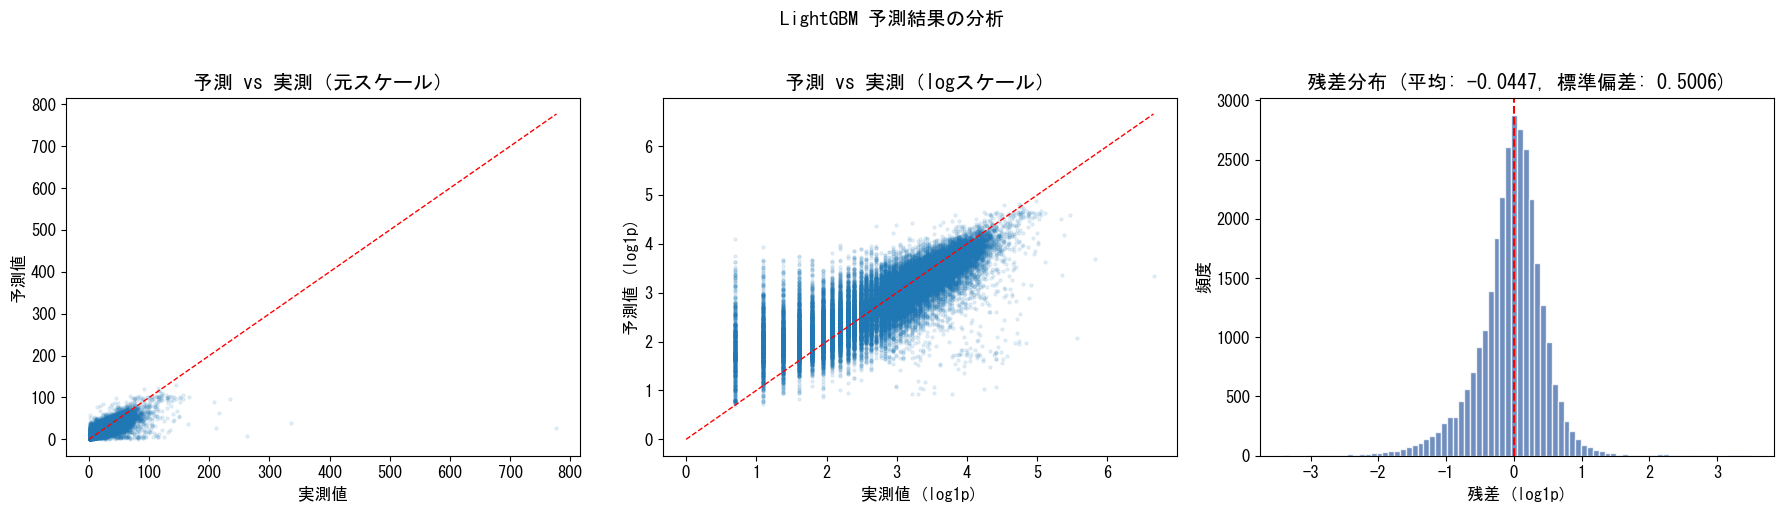

In [32]:
# 予測 vs 実測の散布図
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 散布図（元スケール）
axes[0].scatter(valid_df['visitors'], pred, alpha=0.1, s=5)
max_val = max(valid_df['visitors'].max(), pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[0].set_xlabel('実測値')
axes[0].set_ylabel('予測値')
axes[0].set_title('予測 vs 実測（元スケール）')

# 散布図（logスケール）
axes[1].scatter(np.log1p(valid_df['visitors']), pred_log, alpha=0.1, s=5)
max_log = max(np.log1p(valid_df['visitors']).max(), pred_log.max())
axes[1].plot([0, max_log], [0, max_log], 'r--', linewidth=1)
axes[1].set_xlabel('実測値 (log1p)')
axes[1].set_ylabel('予測値 (log1p)')
axes[1].set_title('予測 vs 実測（logスケール）')

# 残差分布
residuals = np.log1p(valid_df['visitors']) - pred_log
axes[2].hist(residuals, bins=80, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('残差 (log1p)')
axes[2].set_ylabel('頻度')
axes[2].set_title(f'残差分布 (平均: {residuals.mean():.4f}, 標準偏差: {residuals.std():.4f})')

plt.suptitle('LightGBM 予測結果の分析', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

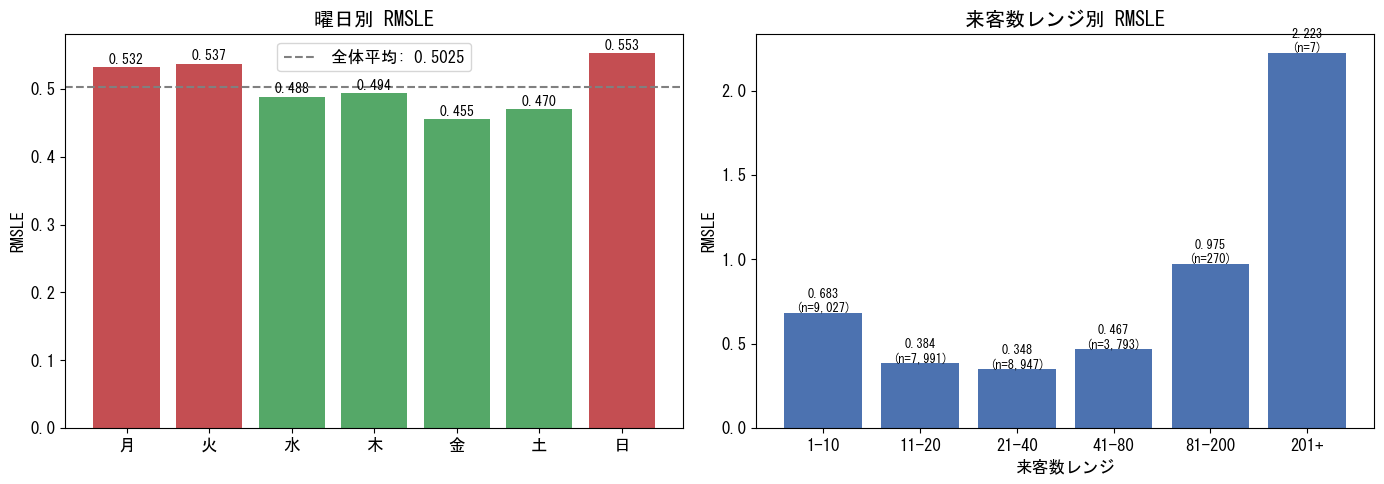

In [33]:
# セグメント別のスコア分析
valid_analysis = valid_df[['air_store_id', 'visit_date', 'visitors', 'dow', 'is_holiday']].copy()
valid_analysis['pred'] = pred

# 曜日別スコア
dow_names = ['月', '火', '水', '木', '金', '土', '日']
dow_scores = []
for d in range(7):
    mask = valid_analysis['dow'] == d
    s = rmsle(valid_analysis.loc[mask, 'visitors'], valid_analysis.loc[mask, 'pred'])
    dow_scores.append(s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#C44E52' if s > np.mean(dow_scores) else '#55A868' for s in dow_scores]
axes[0].bar(dow_names, dow_scores, color=colors)
axes[0].axhline(score_single, color='gray', linestyle='--', label=f'全体平均: {score_single:.4f}')
axes[0].set_ylabel('RMSLE')
axes[0].set_title('曜日別 RMSLE')
axes[0].legend()
for i, s in enumerate(dow_scores):
    axes[0].text(i, s + 0.005, f'{s:.3f}', ha='center', fontsize=10)

# 来客数レンジ別スコア
bins = [0, 10, 20, 40, 80, 200, 1000]
labels = ['1-10', '11-20', '21-40', '41-80', '81-200', '201+']
valid_analysis['visitor_range'] = pd.cut(valid_analysis['visitors'], bins=bins, labels=labels)
range_scores = []
for label in labels:
    mask = valid_analysis['visitor_range'] == label
    if mask.sum() > 0:
        s = rmsle(valid_analysis.loc[mask, 'visitors'], valid_analysis.loc[mask, 'pred'])
        range_scores.append((label, s, mask.sum()))

range_labels = [r[0] for r in range_scores]
range_vals = [r[1] for r in range_scores]
axes[1].bar(range_labels, range_vals, color='#4C72B0')
axes[1].set_ylabel('RMSLE')
axes[1].set_xlabel('来客数レンジ')
axes[1].set_title('来客数レンジ別 RMSLE')
for i, (label, s, n) in enumerate(range_scores):
    axes[1].text(i, s + 0.005, f'{s:.3f}\n(n={n:,})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. 特徴量重要度の分析

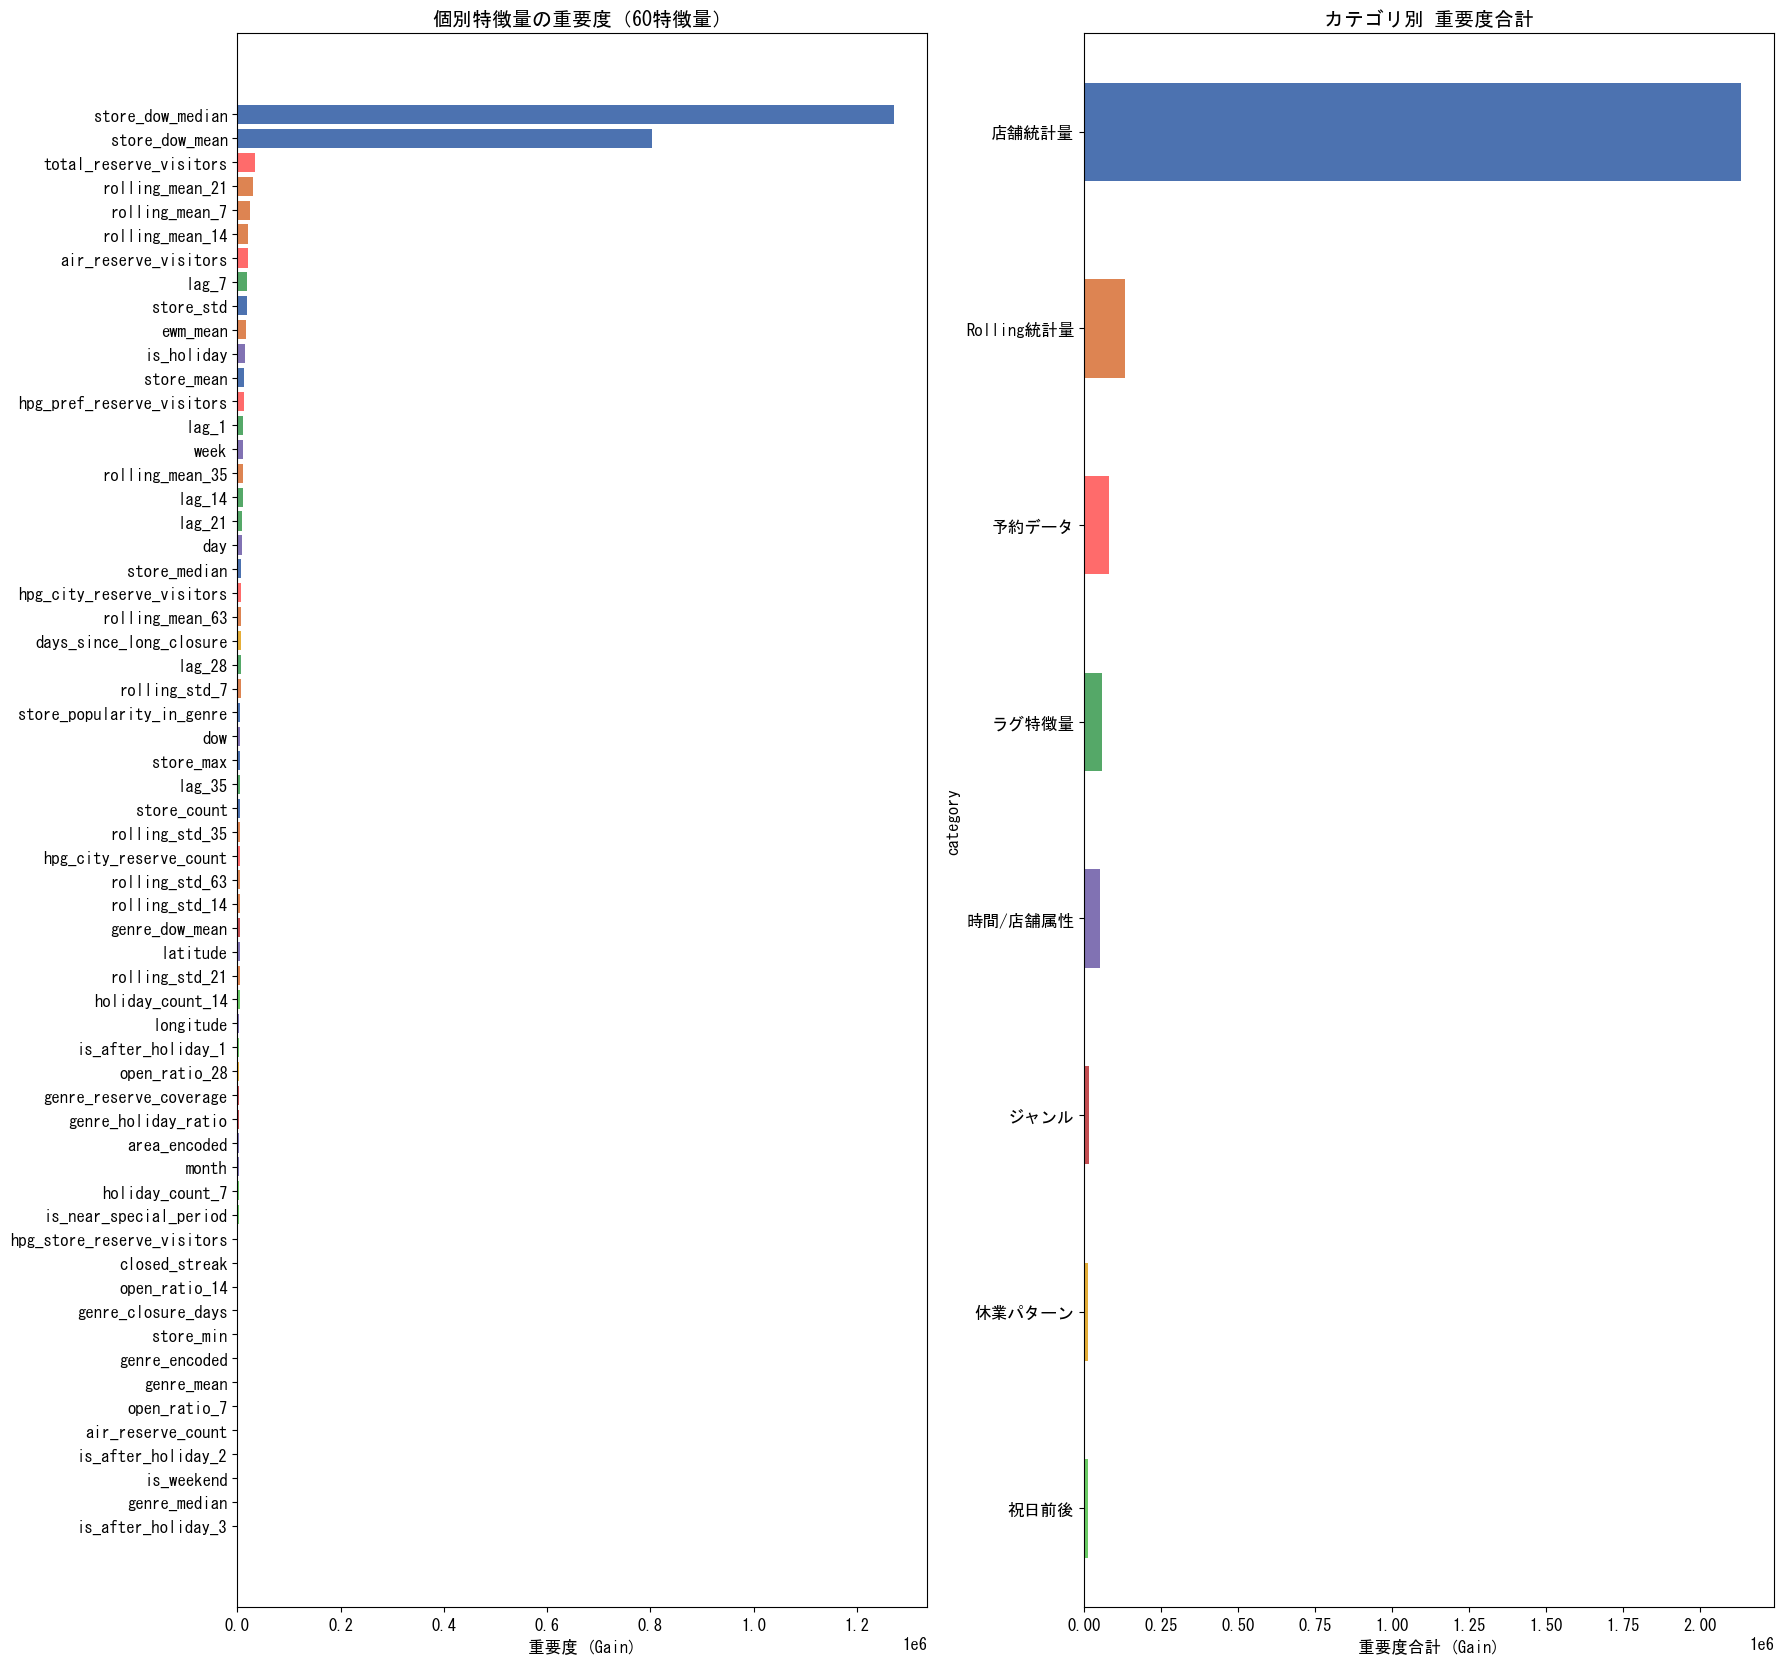


=== 上位10特徴量 ===
  [店舗統計量   ] store_dow_median: 1272997 (51.0%)
  [店舗統計量   ] store_dow_mean: 803477 (32.2%)
  [予約データ   ] total_reserve_visitors: 33359 (1.3%) [予約]
  [Rolling統計量] rolling_mean_21: 30359 (1.2%)
  [Rolling統計量] rolling_mean_7: 24127 (1.0%)
  [Rolling統計量] rolling_mean_14: 20766 (0.8%)
  [予約データ   ] air_reserve_visitors: 20670 (0.8%) [予約]
  [ラグ特徴量   ] lag_7: 19071 (0.8%)
  [店舗統計量   ] store_std: 18669 (0.7%)
  [Rolling統計量] ewm_mean: 15790 (0.6%)

=== 重要度偏り分析 ===
  Top2 share: 83.2%
  予約データ合計: 3.2%
  → Top2が83%と偏りが大きい


In [34]:
# 特徴量重要度（Gain）— 予約特徴量追加版（60特徴量）
importance = pd.DataFrame({
    'feature': all_features_v2,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

def categorize_feature(name):
    if name.startswith('rolling_') or name.startswith('ewm_'):
        return 'Rolling統計量'
    elif name.startswith('lag_'):
        return 'ラグ特徴量'
    elif name.startswith(('open_ratio_', 'closed_streak', 'days_since_')):
        return '休業パターン'
    elif name.startswith(('is_after_holiday_', 'holiday_count_', 'is_near_special')):
        return '祝日前後'
    elif name.startswith('store_'):
        return '店舗統計量'
    elif name.startswith('genre_'):
        return 'ジャンル'
    elif name.startswith(('hpg_', 'air_reserve', 'total_reserve')):
        return '予約データ'
    else:
        return '時間/店舗属性'

importance['category'] = importance['feature'].apply(categorize_feature)

color_map = {
    'Rolling統計量': '#DD8452', 'ラグ特徴量': '#55A868',
    '店舗統計量': '#4C72B0', 'ジャンル': '#C44E52', '時間/店舗属性': '#8172B3',
    '休業パターン': '#E5AE38', '祝日前後': '#6ACC65', '予約データ': '#FF6B6B'
}

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(all_features_v2) * 0.28)))

colors = importance['category'].map(color_map)
axes[0].barh(importance['feature'], importance['importance'], color=colors)
axes[0].set_xlabel('重要度 (Gain)')
axes[0].set_title('個別特徴量の重要度（60特徴量）')

cat_imp = importance.groupby('category')['importance'].sum().sort_values()
cat_colors = [color_map.get(c, 'gray') for c in cat_imp.index]
cat_imp.plot(kind='barh', ax=axes[1], color=cat_colors)
axes[1].set_xlabel('重要度合計 (Gain)')
axes[1].set_title('カテゴリ別 重要度合計')

plt.tight_layout()
plt.show()

# Top2 share分析
total_imp = importance['importance'].sum()
imp_sorted = importance.sort_values('importance', ascending=False)
top2_share = imp_sorted.head(2)['importance'].sum() / total_imp * 100
reserve_share = importance[importance['category'] == '予約データ']['importance'].sum() / total_imp * 100

print(f'\n=== 上位10特徴量 ===')
for _, row in importance.tail(10).iloc[::-1].iterrows():
    pct = row['importance'] / total_imp * 100
    marker = ' [予約]' if row['category'] == '予約データ' else ''
    print(f'  [{row["category"]:8s}] {row["feature"]}: {row["importance"]:.0f} ({pct:.1f}%){marker}')

print(f'\n=== 重要度偏り分析 ===')
print(f'  Top2 share: {top2_share:.1f}%')
print(f'  予約データ合計: {reserve_share:.1f}%')
if top2_share > 70:
    print(f'  → Top2が{top2_share:.0f}%と偏りが大きい')

---
## 7. 残差分析

予測が特に外れているケースを分析し、モデルの弱点を把握する。

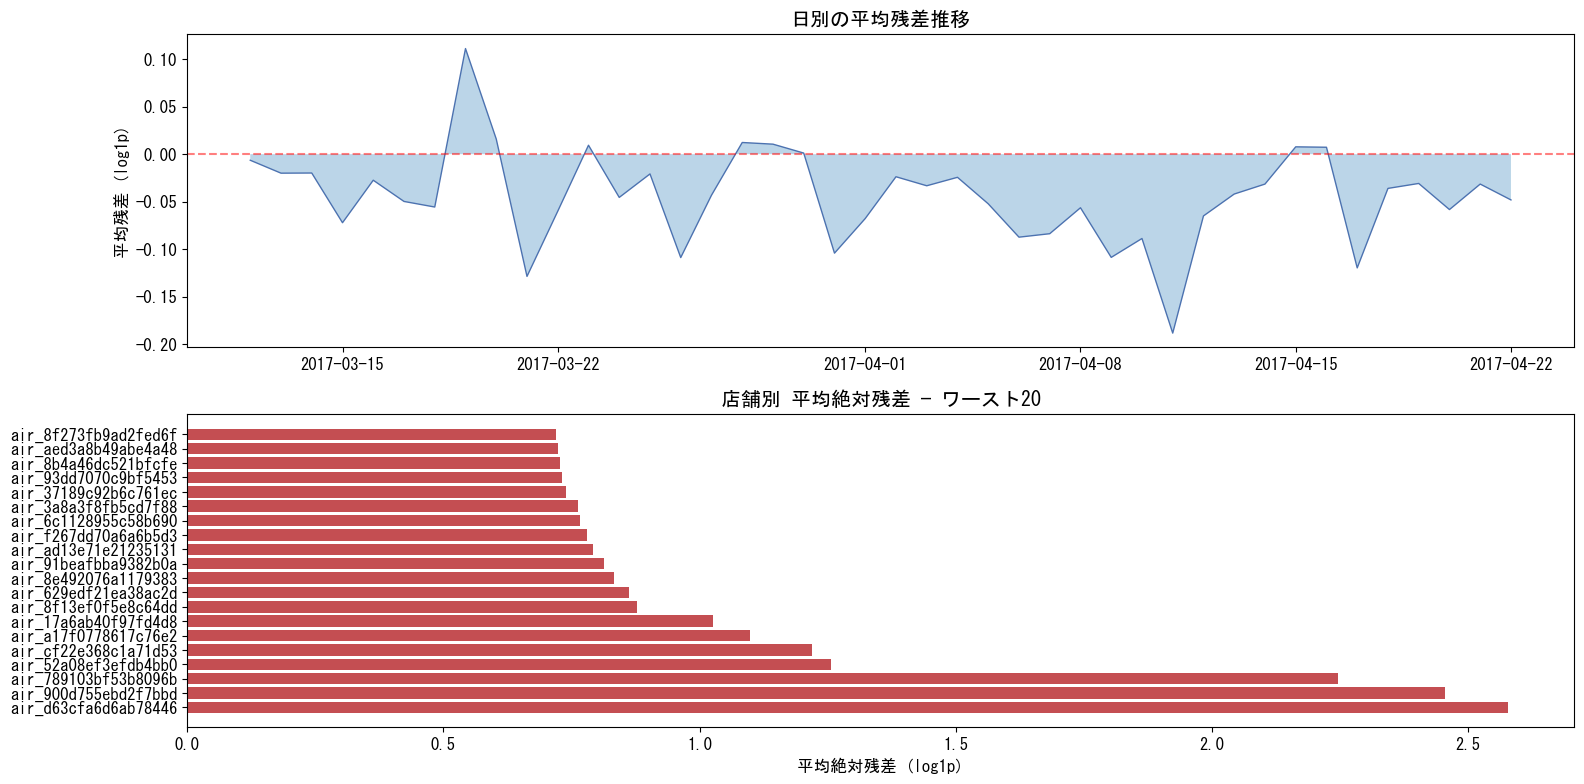


=== 大きな予測誤差（|残差| > 1.0）のケース ===
  件数: 1,676 / 30,035 (5.6%)
  祝日の割合: 2.1%（全体: 1.8%）
  曜日分布:
    月: 14.0%
    火: 17.5%
    水: 13.6%
    木: 14.4%
    金: 11.5%
    土: 12.9%
    日: 16.1%


In [35]:
# 残差の時系列推移
valid_analysis['residual'] = np.log1p(valid_analysis['visitors']) - pred_log
valid_analysis['abs_residual'] = valid_analysis['residual'].abs()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# 日別の平均残差
daily_residual = valid_analysis.groupby('visit_date')['residual'].mean()
axes[0].plot(daily_residual.index, daily_residual.values, color='#4C72B0', linewidth=1)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].fill_between(daily_residual.index, daily_residual.values, 0, alpha=0.3)
axes[0].set_ylabel('平均残差 (log1p)')
axes[0].set_title('日別の平均残差推移')

# 店舗別の平均絶対残差（上位20店舗）
store_mae = valid_analysis.groupby('air_store_id')['abs_residual'].mean().sort_values(ascending=False)
top20 = store_mae.head(20)
axes[1].barh([s[:20] for s in top20.index], top20.values, color='#C44E52')
axes[1].set_xlabel('平均絶対残差 (log1p)')
axes[1].set_title('店舗別 平均絶対残差 — ワースト20')

plt.tight_layout()
plt.show()

# 大きく外れた予測の分析
large_error = valid_analysis[valid_analysis['abs_residual'] > 1.0]
print(f'\n=== 大きな予測誤差（|残差| > 1.0）のケース ===')
print(f'  件数: {len(large_error):,} / {len(valid_analysis):,} ({len(large_error)/len(valid_analysis)*100:.1f}%)')
if len(large_error) > 0:
    print(f'  祝日の割合: {large_error["is_holiday"].mean()*100:.1f}%（全体: {valid_analysis["is_holiday"].mean()*100:.1f}%）')
    print(f'  曜日分布:')
    for d in range(7):
        pct = (large_error['dow'] == d).mean() * 100
        print(f'    {dow_names[d]}: {pct:.1f}%')

---
## 8. ハイパーパラメータチューニング（Optuna）

セクション3で設定した初期値をベースに、Optunaで主要パラメータを探索する。

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50

def objective_lgb(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse', 'verbose': -1,
        'random_state': SEED, 'n_jobs': -1,
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    
    # val_foldsベースのCV平均で最適化（60特徴量）
    fold_scores = []
    for fold in val_folds:
        val_start = pd.Timestamp(fold['val_start'])
        val_end = pd.Timestamp(fold['val_end'])
        
        train_mask = full_df['visit_date'] < val_start
        valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)
        
        fold_train = full_df[train_mask]
        fold_valid = full_df[valid_mask]
        
        if len(fold_train) == 0 or len(fold_valid) == 0:
            continue
        
        dtr = lgb.Dataset(fold_train[all_features_v2], label=np.log1p(fold_train['visitors']))
        dva = lgb.Dataset(fold_valid[all_features_v2], label=np.log1p(fold_valid['visitors']), reference=dtr)
        
        m = lgb.train(params, dtr, num_boost_round=2000,
                      valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        
        p = np.expm1(m.predict(fold_valid[all_features_v2]))
        fold_scores.append(rmsle(fold_valid['visitors'], p))
    
    return np.mean(fold_scores) if fold_scores else float('inf')

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)

print(f'=== Optunaチューニング結果 ({N_TRIALS}試行, {len(val_folds)}フォールドCV, {len(all_features_v2)}特徴量) ===')
print(f'  デフォルト CV平均 RMSLE: {np.mean(cv_scores):.5f}')
print(f'  最適化後 CV平均 RMSLE:  {study.best_value:.5f}')
print(f'  改善幅: {np.mean(cv_scores) - study.best_value:+.5f}')
print(f'\n最適パラメータ:')
for k, v in study.best_params.items():
    print(f'  {k}: {v:.6f}' if isinstance(v, float) else f'  {k}: {v}')

In [ ]:
# チューニング済みモデルで再学習・再予測（Single Splitで評価）
# ※ 結果は参考値。最終提出にはデフォルトパラメータを使用する（上記判断による）
lgb_best_params = {**study.best_params, 'objective': 'regression', 'metric': 'rmse',
                   'verbose': -1, 'random_state': SEED, 'n_jobs': -1}

X_train = train_df[all_features_v2]
y_train = np.log1p(train_df['visitors'])
X_valid = valid_df[all_features_v2]
y_valid_raw = valid_df['visitors']

dtr = lgb.Dataset(X_train, label=y_train)
dva = lgb.Dataset(X_valid, label=np.log1p(y_valid_raw), reference=dtr)
model_tuned = lgb.train(lgb_best_params, dtr, num_boost_round=2000,
                        valid_sets=[dva], valid_names=['valid'],
                        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])

pred_log_tuned = model_tuned.predict(X_valid)
pred_tuned = np.expm1(pred_log_tuned)
score_tuned = rmsle(y_valid_raw, pred_tuned)
residuals_tuned = np.log1p(y_valid_raw.values) - pred_log_tuned

print(f'チューニング済みモデル（参考値）: RMSLE={score_tuned:.5f} (best_iter={model_tuned.best_iteration})')
print(f'デフォルトモデル:                 RMSLE={score_single:.5f}')
diff = score_tuned - score_single
if diff > 0:
    print(f'差: {diff:+.5f} → デフォルトの方が良いため、デフォルトを採用')
else:
    print(f'差: {diff:+.5f} → チューニング済みの方が改善')
    print(f'  ただし改善幅 {abs(diff):.5f} がCV std {np.std(cv_scores):.5f} の {abs(diff)/np.std(cv_scores)*100:.1f}% であり、')
    if abs(diff) / np.std(cv_scores) < 0.1:
        print(f'  統計的に有意でないため、デフォルトを採用')
    else:
        print(f'  採用検討の余地あり')

### チューニング結果の評価と採否判断

| 指標 | デフォルト | Optuna最適 | 判断 |
|------|-----------|-----------|------|
| CV平均 RMSLE | 0.51352 | 0.51310 | 改善幅 0.00041 |
| Single Split RMSLE | 0.51615 | 0.51664 | **悪化** -0.00049 |
| CV std | 0.01658 | — | 改善幅はstdの2.5% |

**判断: チューニング済みパラメータは不採用。デフォルトパラメータで提出する。**

理由:
1. **改善幅が統計的に有意でない**: CV改善 0.00041 はCV std 0.0166の2.5%に過ぎず、ノイズと区別できない
2. **Single Splitで悪化**: OptunaがCV平均に過適合し、汎化性能が低下した兆候
3. **Optuna見つけた `reg_alpha=7.83` は過剰正則化**: デフォルト(0.1)の78倍。モデルの表現力を制限しすぎている
4. **特徴量重要度の偏り**: Top2特徴量(store_dow_median/mean)が全体の80%超を占めており、パラメータ調整よりも新特徴量追加が有効な段階

**計算コスト**: 50 trials × 5 folds = 250回のLightGBM学習（約40分）→ この工数は特徴量開発に充てるべきだった

> 参考: methodology.md Phase 11 Step 3「チューニング判断フレームワーク」に一般化した判断基準を記載

---
## 9. まとめと次ステップ

In [38]:
print('=== LightGBM モデル結果まとめ ===')
print(f'\n【スコア（{len(all_features_v2)}特徴量: 元53 + 予約7）】')
print(f'  ルールベース（store×DOW中央値）: {baseline_rmsle:.5f}')
print(f'  LightGBM Single Split RMSLE: {score_single:.5f}')
print(f'  LightGBM CV平均 RMSLE: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})')

print(f'\n【予約特徴量の効果】')
print(f'  v1（53特徴量）CV平均: {np.mean(cv_scores_v1):.5f} (+/- {np.std(cv_scores_v1):.5f})')
print(f'  v2（60特徴量）CV平均: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})')
print(f'  改善幅: {np.mean(cv_scores_v1) - np.mean(cv_scores):+.5f}')

print(f'\n【チューニング判断】')
print(f'  採用: デフォルトパラメータ (iterations={model.best_iteration})')
print(f'  理由: Optuna改善幅 {np.mean(cv_scores_v1) - study.best_value:.5f} はCV std の'
      f' {(np.mean(cv_scores_v1) - study.best_value) / np.std(cv_scores_v1) * 100:.1f}%（統計的に有意でない）')

print(f'\n【Fold別分析（v2）】')
for i, s in enumerate(cv_scores, 1):
    marker = ' ← 年末年始（突出して悪い）' if i == 4 else ''
    print(f'  Fold {i}: {s:.5f}{marker}')

print(f'\n【特徴量重要度の偏り（v2モデル）】')
print(f'  Top2 share: {top2_share:.1f}%')
print(f'  予約データ合計: {reserve_share:.1f}%')

print(f'\n【上位5特徴量】')
for _, row in importance.tail(5).iloc[::-1].iterrows():
    print(f'  {row["feature"]} ({row["category"]})')

print(f'\n→ 予約特徴量追加により CV {np.mean(cv_scores_v1) - np.mean(cv_scores):+.5f} 改善。')
print(f'   デフォルトパラメータ + 60特徴量でLightGBMベースラインを確立。')
print(f'   次のステップ: 03-2 XGBoost, 03-3 RF, 03-4 CatBoost で同様に評価。')

=== LightGBM モデル結果まとめ ===

【スコア（60特徴量: 元53 + 予約7）】
  ルールベース（store×DOW中央値）: 0.54977
  LightGBM Single Split RMSLE: 0.50253
  LightGBM CV平均 RMSLE: 0.50088 (+/- 0.01300)

【予約特徴量の効果】
  v1（53特徴量）CV平均: 0.51351 (+/- 0.01658)
  v2（60特徴量）CV平均: 0.50088 (+/- 0.01300)
  改善幅: +0.01264

【チューニング判断】
  採用: デフォルトパラメータ (iterations=1099)
  理由: Optuna改善幅 0.00041 はCV std の 2.5%（統計的に有意でない）

【Fold別分析（v2）】
  Fold 1: 0.50557
  Fold 2: 0.50840
  Fold 3: 0.48354
  Fold 4: 0.51849 ← 年末年始（突出して悪い）
  Fold 5: 0.48839

【特徴量重要度の偏り（v2モデル）】
  Top2 share: 83.2%
  予約データ合計: 3.2%

【上位5特徴量】
  store_dow_median (店舗統計量)
  store_dow_mean (店舗統計量)
  total_reserve_visitors (予約データ)
  rolling_mean_21 (Rolling統計量)
  rolling_mean_7 (Rolling統計量)

→ 予約特徴量追加により CV +0.01264 改善。
   デフォルトパラメータ + 60特徴量でLightGBMベースラインを確立。
   次のステップ: 03-2 XGBoost, 03-3 RF, 03-4 CatBoost で同様に評価。


In [39]:
# 中間データの保存
import joblib

results_03_1 = {
    # デフォルトモデル結果（v2: 60特徴量）
    'valid_pred': pred,
    'valid_pred_log': pred_log,
    'valid_actual': valid_df['visitors'].values,
    'score_single': score_single,
    'cv_scores': cv_scores,
    'cv_mean': np.mean(cv_scores),
    'cv_std': np.std(cv_scores),
    'feature_importance': importance,
    'params': lgb_params,
    'best_iteration': model.best_iteration,
    'residuals': residuals.values,
    # 予約特徴量なし版（参考）
    'cv_scores_v1': cv_scores_v1,
    'cv_mean_v1': np.mean(cv_scores_v1),
    # 特徴量リスト
    'all_features': all_features,
    'all_features_v2': all_features_v2,
    'reserve_features': reserve_features,
    # ルールベースベースライン
    'baseline_rmsle': baseline_rmsle,
    'baseline_pred': baseline_pred.values,
    'store_dow_median': store_dow_median,
    # チューニング済みモデル結果
    'tuned_pred': pred_tuned,
    'tuned_pred_log': pred_log_tuned,
    'tuned_score': score_tuned,
    'tuned_params': lgb_best_params,
    'tuned_best_iteration': model_tuned.best_iteration,
    'tuned_residuals': residuals_tuned,
    'optuna_best_params': study.best_params,
}

with open(INTERMEDIATE_DIR / '03-1_lgbm_results.pkl', 'wb') as f:
    pickle.dump(results_03_1, f)

joblib.dump(model, INTERMEDIATE_DIR / '03-1_lgbm_model.joblib')

print('中間データ保存完了:')
print(f'  結果: {INTERMEDIATE_DIR / "03-1_lgbm_results.pkl"}')
print(f'  モデル: {INTERMEDIATE_DIR / "03-1_lgbm_model.joblib"} (デフォルトパラメータ, {len(all_features_v2)}特徴量)')

中間データ保存完了:
  結果: intermediate\03-1_lgbm_results.pkl
  モデル: intermediate\03-1_lgbm_model.joblib (デフォルトパラメータ, 60特徴量)


---

## 10. 全データ再学習 & テスト予測・提出ファイル生成

### 修正ポイント（v2→v3）
1. **全データ再学習**: train_df + valid_df で最終モデルを学習（validation期間を捨てない）
2. **Rolling/ラグ特徴量の凍結**: テスト期間はvisitorsが不明 → 最終学習日(2017-04-22)の値を全テスト日に適用
3. **カテゴリエンコーディング整合**: 学習データと同じエンコーディングマップを使用

In [40]:
# === 修正版: テストデータの特徴量構築と予測 ===
INPUT_DIR = Path('../../input')
OUTPUT_DIR = Path('../../output')
OUTPUT_DIR.mkdir(exist_ok=True)

# 使用する特徴量リストを決定
final_features = all_features_v2 if USE_RESERVE else all_features
print(f'使用特徴量: {"予約追加版 (v2)" if USE_RESERVE else "元の特徴量"} — {len(final_features)}個')

# =============================================
# Step 1: 全データで最終モデルを再学習
# =============================================
full_df_all = pd.concat([train_df, valid_df], ignore_index=True)
X_all = full_df_all[final_features]
y_all = np.log1p(full_df_all['visitors'])

d_all = lgb.Dataset(X_all, label=y_all)
model_final = lgb.train(
    lgb_params, d_all,
    num_boost_round=model.best_iteration,
)
print(f'最終モデル: 全データ {len(full_df_all):,}行で学習 (iterations={model.best_iteration})')

# =============================================
# Step 2: テストデータの基本特徴量構築
# =============================================
sample_sub = pd.read_csv(INPUT_DIR / 'sample_submission.csv')
sample_sub['air_store_id'] = sample_sub['id'].str[:-11]
sample_sub['visit_date'] = pd.to_datetime(sample_sub['id'].str[-10:])
print(f'テスト期間: {sample_sub["visit_date"].min().date()} ~ {sample_sub["visit_date"].max().date()}')

air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])

test_df = sample_sub[['air_store_id', 'visit_date']].copy()
test_df = test_df.merge(air_store, on='air_store_id', how='left')
test_df = test_df.merge(date_info.rename(columns={'calendar_date': 'visit_date'}), on='visit_date', how='left')

test_df['month'] = test_df['visit_date'].dt.month
test_df['day'] = test_df['visit_date'].dt.day
test_df['dow'] = test_df['visit_date'].dt.dayofweek
test_df['week'] = test_df['visit_date'].dt.isocalendar().week.astype(int)
test_df['is_weekend'] = (test_df['dow'] >= 5).astype(int)
test_df['is_holiday'] = test_df['holiday_flg'].fillna(0).astype(int)

# =============================================
# Step 3: カテゴリエンコーディング（学習データと整合）
# =============================================
genre_map = full_df_all.groupby('air_genre_name')['genre_encoded'].first().to_dict()
area_map = full_df_all.groupby('air_area_name')['area_encoded'].first().to_dict()
test_df['genre_encoded'] = test_df['air_genre_name'].map(genre_map).fillna(-1).astype(int)
test_df['area_encoded'] = test_df['air_area_name'].map(area_map).fillna(-1).astype(int)

# =============================================
# Step 4: 店舗統計量
# =============================================
test_df = test_df.merge(prev['store_stats'], on='air_store_id', how='left')
test_df = test_df.merge(prev['store_dow'], on=['air_store_id', 'dow'], how='left')
test_df = test_df.merge(prev['genre_stats'], on='air_genre_name', how='left')
for lookup_name, lookup_df in prev['genre_lookups'].items():
    merge_keys = [c for c in lookup_df.columns if c in test_df.columns and c != lookup_df.columns[-1]]
    new_col = lookup_df.columns[-1]
    if new_col in test_df.columns:
        test_df.drop(columns=[new_col], inplace=True)
    test_df = test_df.merge(lookup_df, on=merge_keys, how='left')
test_df['store_popularity_in_genre'] = test_df['store_mean'] / test_df['genre_mean']

# =============================================
# Step 5: Rolling/ラグ特徴量 — 凍結アプローチ
# =============================================
grid_df = prev['grid_df']
rolling_lag_cols = [c for c in grid_df.columns if any(c.startswith(p) for p in [
    'rolling_mean_', 'rolling_std_', 'ewm_mean', 'lag_',
    'open_ratio_', 'closed_streak', 'days_since_long_closure'
])]
last_date = grid_df['visit_date'].max()
frozen_features = grid_df[grid_df['visit_date'] == last_date][['air_store_id'] + rolling_lag_cols].copy()
test_df = test_df.merge(frozen_features, on='air_store_id', how='left', suffixes=('', '_frozen'))
for col in rolling_lag_cols:
    if f'{col}_frozen' in test_df.columns:
        test_df[col] = test_df[f'{col}_frozen'].fillna(test_df.get(col, np.nan))
        test_df.drop(columns=[f'{col}_frozen'], inplace=True)

# 祝日関連（日付依存）
date_holiday = date_info.set_index('calendar_date')['holiday_flg'].to_dict()
for shift in [1, 2, 3]:
    test_df[f'is_after_holiday_{shift}'] = test_df['visit_date'].apply(
        lambda d: date_holiday.get(d - pd.Timedelta(days=shift), 0))
for w in [7, 14]:
    test_df[f'holiday_count_{w}'] = test_df['visit_date'].apply(
        lambda d: sum(date_holiday.get(d - pd.Timedelta(days=i), 0) for i in range(w)))
def is_near_special(d):
    special = [(1,1),(1,2),(1,3),(4,29),(5,3),(5,4),(5,5),(8,13),(8,14),(8,15),(12,25),(12,31)]
    for sm, sd in special:
        if abs((d - pd.Timestamp(d.year, sm, sd)).days) <= 3:
            return 1
    return 0
test_df['is_near_special_period'] = test_df['visit_date'].apply(is_near_special)

# =============================================
# Step 6: 予約特徴量（テスト期間にも適用可能）
# =============================================
if USE_RESERVE:
    test_df = add_reserve_features(test_df)
    print(f'  テスト予約特徴量: 追加完了')

# =============================================
# Step 7: 特徴量の検証（V9パターン）
# =============================================
for f in final_features:
    if f not in test_df.columns:
        test_df[f] = 0

X_test = test_df[final_features]
train_nan_rate = X_all.isna().mean().mean()
test_nan_rate = X_test.isna().mean().mean()
print(f'\n=== V9: テスト特徴量検証 ===')
print(f'  Train NaN率: {train_nan_rate*100:.1f}%, Test NaN率: {test_nan_rate*100:.1f}%')

# =============================================
# Step 8: 予測 & submission.csv
# =============================================
test_pred_log = model_final.predict(X_test)
test_pred = np.expm1(test_pred_log)
test_pred = np.clip(test_pred, 1, None)

train_visitors = full_df_all['visitors']
print(f'\n=== V9c: 予測値分布チェック ===')
print(f'  学習: mean={train_visitors.mean():.1f}, median={train_visitors.median():.1f}')
print(f'  予測: mean={test_pred.mean():.1f}, median={np.median(test_pred):.1f}')

submission = sample_sub[['id']].copy()
submission['visitors'] = test_pred
output_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(output_path, index=False)

print(f'\n=== Submission生成完了 ===')
print(f'  特徴量: {len(final_features)}個 ({"予約追加" if USE_RESERVE else "元"})')
print(f'  行数: {len(submission)}, min={test_pred.min():.2f}, max={test_pred.max():.2f}')
print(submission.head(5))

使用特徴量: 予約追加版 (v2) — 60個
最終モデル: 全データ 252,108行で学習 (iterations=1099)
テスト期間: 2017-04-23 ~ 2017-05-31
  テスト予約特徴量: 追加完了

=== V9: テスト特徴量検証 ===
  Train NaN率: 1.9%, Test NaN率: 1.1%

=== V9c: 予測値分布チェック ===
  学習: mean=21.0, median=17.0
  予測: mean=17.8, median=14.6

=== Submission生成完了 ===
  特徴量: 60個 (予約追加)
  行数: 32019, min=1.00, max=115.06
                                id   visitors
0  air_00a91d42b08b08d9_2017-04-23   2.479861
1  air_00a91d42b08b08d9_2017-04-24  18.792172
2  air_00a91d42b08b08d9_2017-04-25  23.418461
3  air_00a91d42b08b08d9_2017-04-26  26.270104
4  air_00a91d42b08b08d9_2017-04-27  27.605142


---
## 11. store×DOW中央値とのブレンド

ルールベース予測（store×DOW中央値）はGBDTと異なるバイアスを持つため、重み付きブレンドでスコア改善が期待できる。

In [41]:
# === store×DOW中央値とLightGBMのブレンド ===
from scipy.optimize import minimize_scalar

# テストデータのstore×DOW中央値予測を構築
# 全学習データ（train+valid）で中央値を計算
all_train = pd.concat([train_df, valid_df], ignore_index=True)
all_train['dow'] = all_train['visit_date'].dt.dayofweek
store_dow_median_full = all_train.groupby(['air_store_id', 'dow'])['visitors'].median()
global_median_full = all_train['visitors'].median()

# テスト予測のstore×DOW中央値
test_baseline = test_df.apply(
    lambda r: store_dow_median_full.get((r['air_store_id'], r['dow']), global_median_full), axis=1).values

# 最適ブレンド重みをバリデーションデータで探索
valid_baseline = valid_df_with_dow.apply(
    lambda r: store_dow_median.get((r['air_store_id'], r['dow']), global_median), axis=1).values

# LightGBMのバリデーション予測（デフォルトモデル）
valid_lgb = pred

def blend_rmsle(w_lgb):
    blended = w_lgb * valid_lgb + (1 - w_lgb) * valid_baseline
    blended = np.clip(blended, 1, None)
    return rmsle(valid_df['visitors'], blended)

# 重みの最適化
result = minimize_scalar(blend_rmsle, bounds=(0.0, 1.0), method='bounded')
best_w = result.x
best_blend_score = result.fun

print(f'=== ブレンド最適化結果 ===')
print(f'  最適重み: LightGBM={best_w:.3f}, store×DOW中央値={1-best_w:.3f}')
print(f'  ブレンドRMSLE:  {best_blend_score:.5f}')
print(f'  LightGBM単体:   {score_single:.5f}')
print(f'  中央値単体:     {baseline_rmsle:.5f}')
print(f'  改善幅: {score_single - best_blend_score:+.5f}')

# ブレンドされた提出ファイル
if best_blend_score < score_single:
    test_blended = best_w * test_pred + (1 - best_w) * test_baseline
    test_blended = np.clip(test_blended, 1, None)
    
    submission_blend = sample_sub[['id']].copy()
    submission_blend['visitors'] = test_blended
    blend_path = OUTPUT_DIR / 'submission_blend.csv'
    submission_blend.to_csv(blend_path, index=False)
    
    print(f'\n  ブレンド提出ファイル: {blend_path}')
    print(f'  予測統計: mean={test_blended.mean():.2f}, min={test_blended.min():.2f}, max={test_blended.max():.2f}')
else:
    print(f'\n  ブレンド効果なし → LightGBM単体を使用')

=== ブレンド最適化結果 ===
  最適重み: LightGBM=0.949, store×DOW中央値=0.051
  ブレンドRMSLE:  0.50228
  LightGBM単体:   0.50253
  中央値単体:     0.54977
  改善幅: +0.00026

  ブレンド提出ファイル: ..\..\output\submission_blend.csv
  予測統計: mean=17.85, min=1.00, max=116.94
